In [12]:
import pandas as pd
import numpy as np

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error

In [14]:
import shap
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
print("All libraries loaded ✓")

All libraries loaded ✓


In [15]:
df = pd.read_excel(
    "../data/ML_Dataset_Aim3.xlsx",
    sheet_name="HFILOH Dwell time",
    header =3
)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Shape: (60, 27)
Columns: ['Row ID', 'Concentration\n(g/L)', 'Dwell Time\n(s)', 'Withdrawal\nSpeed (mm/s)', '–OH Count\n(cation)', 'F Chain\nLength', 'F Count\n(cation)', 'F Count\n(anion)', 'HBD\n(cation)', 'HBA\n(cation)', 'TPSA\n(cation, Å²)', 'Rot. Bonds\n(cation)', 'Ring Count\n(cation)', 'MW Cation\n(g/mol)', 'MW Anion\n(g/mol)', 'Bonded\nThickness (nm)', 'Bonded\nThickness_SD', 'Mobile\nThickness (nm)', 'Mobile\nThickness_SD', 'Total\nThickness (nm)', 'Total\nThickness_SD', 'Bonded\nFraction', 'WCA (°)', 'Unnamed: 23', 'HCA (°)', 'Unnamed: 25', 'Notes / data source']


,Row ID,Concentration\n(g/L),Dwell Time\n(s),Withdrawal\nSpeed (mm/s),–OH Count\n(cation),F Chain\nLength,F Count\n(cation),F Count\n(anion),HBD\n(cation),HBA\n(cation),...,Mobile\nThickness (nm),Mobile\nThickness_SD,Total\nThickness (nm),Total\nThickness_SD,Bonded\nFraction,WCA (°),Unnamed: 23,HCA (°),Unnamed: 25,Notes / data source
0,HFILOH-DS-001,0.5,30.0,1.0,1.0,6.0,13.0,18.0,1.0,3.0,...,0.633333,0.018257,0.823333,0.015275,0.230769,NaN,NaN,NaN,NaN,NaN
1,HFILOH-DS-002,0.5,60.0,1.0,1.0,6.0,13.0,18.0,1.0,3.0,...,0.551111,0.030505,0.982222,0.025874,0.438914,NaN,NaN,NaN,NaN,NaN
2,HFILOH-DS-003,0.5,90.0,1.0,1.0,6.0,13.0,18.0,1.0,3.0,...,0.537778,0.035158,0.966667,0.018028,0.443678,NaN,NaN,NaN,NaN,NaN
3,HFILOH-DS-004,0.5,120.0,1.0,1.0,6.0,13.0,18.0,1.0,3.0,...,0.516667,0.058571,0.987778,0.032702,0.476940,NaN,NaN,NaN,NaN,NaN
4,HFILOH-DS-005,0.5,150.0,1.0,1.0,6.0,13.0,18.0,1.0,3.0,...,0.514444,0.026247,1.008889,0.013642,0.490088,NaN,NaN,NaN,NaN,NaN


In [16]:
targets = [
    "Bonded\nThickness (nm)",
    "Mobile\nThickness (nm)", 
    "Bonded\nFraction",
    "WCA (°)",
    "HCA (°)"
]

print("Data coverage per target:")
for t in targets:
    if t in df.columns:
        n = df[t].notna().sum()
        print(f"  {t:30s}  {n}/{len(df)} rows filled")
    else:
        print(f"  {t:30s}  column not found")

Data coverage per target:
  Bonded
Thickness (nm)           41/60 rows filled
  Mobile
Thickness (nm)           41/60 rows filled
  Bonded
Fraction                 41/60 rows filled
  WCA (°)                         0/60 rows filled
  HCA (°)                         0/60 rows filled


In [17]:
FEATURE_COLS = [
    "Concentration\n(g/L)",
    "Dwell Time\n(s)",
]

TARGET = "Bonded\nFraction"


# Drop rows where target is missing
df_model = df.dropna(subset=[TARGET]).copy()
print(f"Rows available for training: {len(df_model)}")

X = df_model[FEATURE_COLS].values
y = df_model[TARGET].values

# Scale features to [0, 1]
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"X shape: {X_scaled.shape}")
print(f"y range: {y.min():.3f} – {y.max():.3f}")

Rows available for training: 41
X shape: (41, 2)
y range: 0.157 – 0.615


In [18]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.model_selection import LeaveOneOut, cross_val_score

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=4, random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, max_depth=3,
        learning_rate=0.05, random_state=42
    ),
    "Gaussian Process": GaussianProcessRegressor(
        kernel=ConstantKernel(1.0) * RBF(1.0) + WhiteKernel(0.01),
        normalize_y=True, random_state=42
    ),
}

loo = LeaveOneOut()

print(f"{'Model':22s}  {'R²':>8}  {'MAE':>8}")
print("-" * 45)

results = {}
for name, model in models.items():
    r2  = cross_val_score(model, X_scaled, y, cv=loo, scoring="r2")
    mae = cross_val_score(model, X_scaled, y, cv=loo,
                          scoring="neg_mean_absolute_error")
    results[name] = {"R2": r2.mean(), "MAE": -mae.mean()}
    print(f"{name:22s}  {r2.mean():8.3f}  {-mae.mean():8.4f}")

Model                         R²       MAE
---------------------------------------------
Random Forest                nan    0.0268
Gradient Boosting            nan    0.0275
Gaussian Process             nan    0.0810


In [19]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=4, random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, max_depth=3,
        learning_rate=0.05, random_state=42
    ),
    "Gaussian Process": GaussianProcessRegressor(
        kernel=ConstantKernel(1.0) * RBF(1.0) + WhiteKernel(0.01),
        normalize_y=True, random_state=42
    ),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model':22s}  {'R²':>8}  {'MAE':>8}")
print("-" * 45)

results = {}
for name, model in models.items():
    # cross_val_predict gives prediction for each sample
    y_pred = cross_val_predict(model, X_scaled, y, cv=kf)
    r2  = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    results[name] = {"R2": r2, "MAE": mae, "y_pred": y_pred}
    print(f"{name:22s}  {r2:8.3f}  {mae:8.4f}")

Model                         R²       MAE
---------------------------------------------
Random Forest              0.853    0.0310
Gradient Boosting          0.858    0.0305
Gaussian Process          -0.051    0.0819


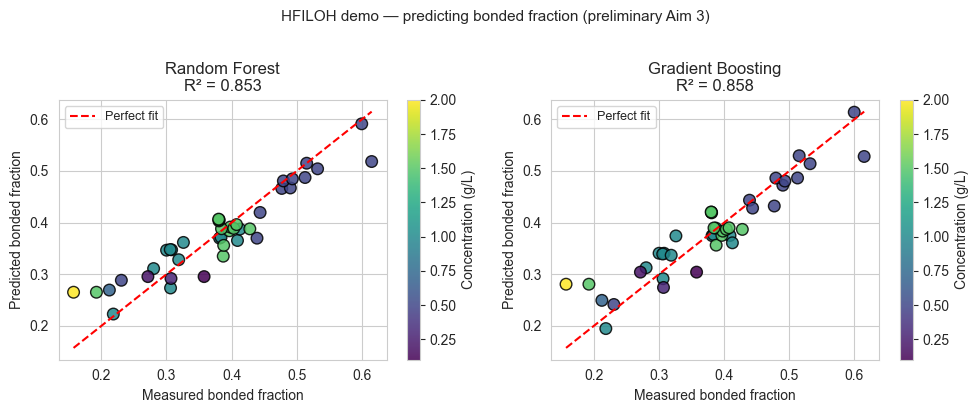

Figure saved ✓


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, name in zip(axes, ["Random Forest", "Gradient Boosting"]):
    y_pred = results[name]["y_pred"]
    r2     = results[name]["R2"]

    sc = ax.scatter(y, y_pred,
                    c=df_model["Concentration\n(g/L)"],
                    cmap="viridis", edgecolors="k",
                    s=70, alpha=0.85)
    ax.plot([y.min(), y.max()], [y.min(), y.max()],
            "r--", lw=1.5, label="Perfect fit")
    plt.colorbar(sc, ax=ax, label="Concentration (g/L)")
    ax.set_xlabel("Measured bonded fraction")
    ax.set_ylabel("Predicted bonded fraction")
    ax.set_title(f"{name}\nR² = {r2:.3f}")
    ax.legend(fontsize=9)

plt.suptitle("HFILOH demo — predicting bonded fraction (preliminary Aim 3)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("../data/01_predicted_vs_actual.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved ✓")


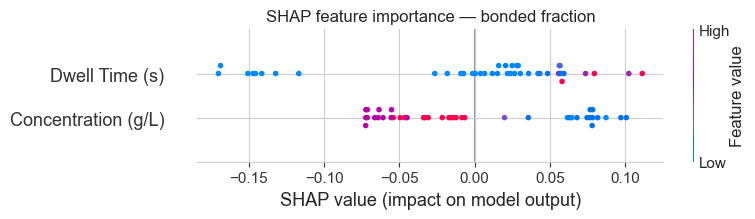

SHAP plot saved ✓


In [21]:
import shap

# Fit Random Forest on full dataset
rf = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
rf.fit(X_scaled, y)

# SHAP values
explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(X_scaled)

# Rename features for cleaner plot labels
feature_labels = ["Concentration (g/L)", "Dwell Time (s)"]

plt.figure(figsize=(6, 4))
shap.summary_plot(
    shap_vals, X_scaled,
    feature_names=feature_labels,
    show=False
)
plt.title("SHAP feature importance — bonded fraction")
plt.tight_layout()
plt.savefig("../data/02_shap_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("SHAP plot saved ✓")

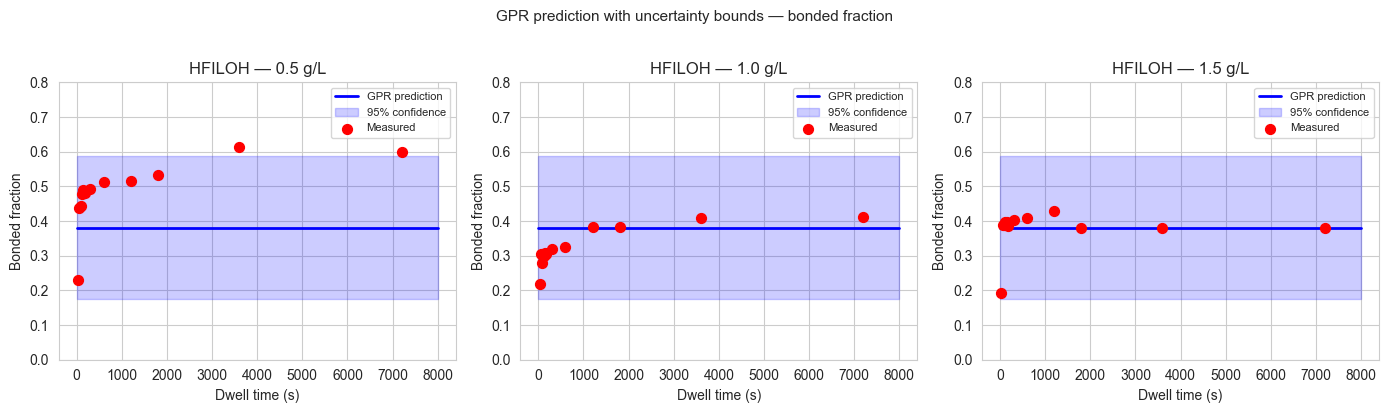

GPR plot saved ✓


In [22]:
# Refit GPR on full dataset
gpr = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0) * RBF(1.0) + WhiteKernel(0.01),
    normalize_y=True, random_state=42
)
gpr.fit(X_scaled, y)

dwell_grid = np.linspace(0, 8000, 300)
fig, axes  = plt.subplots(1, 3, figsize=(14, 4))

for ax, conc in zip(axes, [0.5, 1.0, 1.5]):
    # Build prediction grid for this concentration
    X_grid = np.column_stack([
        np.full(300, conc),
        dwell_grid
    ])
    X_grid_scaled       = scaler.transform(X_grid)
    y_mean, y_std       = gpr.predict(X_grid_scaled, return_std=True)

    # Plot prediction and uncertainty band
    ax.plot(dwell_grid, y_mean, "b-", lw=2, label="GPR prediction")
    ax.fill_between(dwell_grid,
                    y_mean - 2*y_std,
                    y_mean + 2*y_std,
                    alpha=0.2, color="blue", label="95% confidence")

    # Overlay actual data points
    mask = df_model["Concentration\n(g/L)"] == conc
    ax.scatter(
        df_model.loc[mask, "Dwell Time\n(s)"],
        df_model.loc[mask, TARGET],
        color="red", zorder=5, s=50, label="Measured"
    )

    ax.set_xlabel("Dwell time (s)")
    ax.set_ylabel("Bonded fraction")
    ax.set_title(f"HFILOH — {conc} g/L")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 0.8)

plt.suptitle("GPR prediction with uncertainty bounds — bonded fraction",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("../data/03_gpr_uncertainty.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("GPR plot saved ✓")

In [23]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
y_dummy = cross_val_predict(dummy, X_scaled, y, cv=kf)
r2_dummy = r2_score(y, y_dummy)
print(f"Dummy baseline R² = {r2_dummy:.3f}")
# Should be ~0.0 — confirms your model is actually learning something

Dummy baseline R² = -0.051


In [25]:
import math

KIN = {
    0.5: {"y0": 0.445, "A0": 0.301, "tau": 2080.7,  "mobile": 0.50},
    1.0: {"y0": 0.400, "A0": 0.372, "tau": 1451.2,  "mobile": 1.00},
    1.5: {"y0": 0.709, "A0": 0.097, "tau": 314.1,   "mobile": 1.20},
}

def kinetic_bf(conc, dwell):
    conc_rounded = round(float(conc), 1)
    if conc_rounded not in KIN:
        return None   # skip concentrations without kinetic parameters
    p = KIN[conc_rounded]
    bonded = p["y0"] + p["A0"] * (1 - math.exp(-dwell / p["tau"]))
    total  = bonded + p["mobile"]
    return bonded / total

# Only use rows where kinetic parameters exist
conc_col  = df_model["Concentration\n(g/L)"].values
dwell_col = df_model["Dwell Time\n(s)"].values

kinetic_results = [
    (kinetic_bf(c, d), y_val)
    for c, d, y_val in zip(conc_col, dwell_col, y)
    if kinetic_bf(round(float(c), 1), d) is not None
]

y_kinetic_filtered = [r[0] for r in kinetic_results]
y_actual_filtered  = [r[1] for r in kinetic_results]

r2_kinetic  = r2_score(y_actual_filtered, y_kinetic_filtered)
mae_kinetic = mean_absolute_error(y_actual_filtered, y_kinetic_filtered)

print(f"Comparison on {len(y_kinetic_filtered)} rows with known kinetic parameters:")
print(f"{'Model':22s}  {'R²':>8}  {'MAE':>8}")
print("-" * 45)
print(f"{'Dummy (mean)':22s}  {-0.051:8.3f}  {'—':>8}")
print(f"{'Kinetic model':22s}  {r2_kinetic:8.3f}  {mae_kinetic:8.4f}")
print(f"{'Random Forest':22s}  {results['Random Forest']['R2']:8.3f}  {results['Random Forest']['MAE']:8.4f}")
print(f"{'Gradient Boosting':22s}  {results['Gradient Boosting']['R2']:8.3f}  {results['Gradient Boosting']['MAE']:8.4f}")

Comparison on 36 rows with known kinetic parameters:
Model                         R²       MAE
---------------------------------------------
Dummy (mean)              -0.051         —
Kinetic model              0.680    0.0261
Random Forest              0.853    0.0310
Gradient Boosting          0.858    0.0305
